# Week 2-3 Sold Dataset EDA Questions

This notebook answers the required EDA questions before moving to cleaning:

- What is the Residential vs. other property type share?
- What are the median and average close prices?
- What does the Days on Market distribution look like?
- What percentage of homes sold above vs. below list price?
- Are there any apparent date consistency issues?
- Which counties have the highest median prices?

## 1. Import Packages And Set Paths

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "data" / "reports" / "week2_3_sold_questions"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

START_MONTH = "202401"
END_MONTH = "202605"

## 2. Load All Sold Files

We load the raw monthly sold files instead of the processed Residential-only file because the first question requires Residential vs. non-Residential share.

In [8]:
def month_range(start_month, end_month):
    year = int(start_month[:4])
    month = int(start_month[4:])
    end_year = int(end_month[:4])
    end_month_num = int(end_month[4:])

    while (year, month) <= (end_year, end_month_num):
        yield f"{year}{month:02d}"
        month += 1
        if month == 13:
            month = 1
            year += 1


def select_sold_file(month):
    filled_file = RAW_DIR / f"CRMLSSold{month}_filled.csv"
    regular_file = RAW_DIR / f"CRMLSSold{month}.csv"

    if filled_file.exists():
        return filled_file
    if regular_file.exists():
        return regular_file
    return None


frames = []
missing_months = []

for month in month_range(START_MONTH, END_MONTH):
    file_path = select_sold_file(month)
    if file_path is None:
        missing_months.append(month)
        continue

    df = pd.read_csv(file_path, low_memory=False)

    # Boss note: *_filled files include two extra helper columns at the end.
    if file_path.stem.endswith("_filled"):
        df = df.iloc[:, :-2]

    df["SourceMonth"] = month
    df["SourceFile"] = file_path.name
    frames.append(df)

sold_all = pd.concat(frames, ignore_index=True, sort=False)

print(f"Rows loaded: {len(sold_all):,}")
print(f"Columns loaded: {sold_all.shape[1]:,}")
print(f"Missing months: {missing_months if missing_months else 'none'}")
sold_all.head()

Rows loaded: 639,922
Columns loaded: 84
Missing months: none


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,SourceMonth,SourceFile,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,94401,6472.0,NaN,NaN,202401,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,92394,NaN,52320.0,NaN,202401,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,93240,NaN,217364.0,NaN,202401,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,92308,NaN,217800.0,NaN,202401,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,93544,0.0,108883.0,NaN,202401,CRMLSSold202401_filled.csv,NaN,NaN,NaN,NaN


## 3. What Is The Residential Vs. Other Property Type Share?

In [9]:
property_type_summary = (
    sold_all["PropertyType"]
    .fillna("Missing")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .reset_index()
)
property_type_summary.columns = ["PropertyType", "row_count"]
property_type_summary["share_pct"] = (
    property_type_summary["row_count"] / len(sold_all) * 100
).round(2)

property_type_summary

,PropertyType,row_count,share_pct
0,Residential,430454,67.27
1,ResidentialLease,146562,22.90
2,Land,20727,3.24
3,ManufacturedInPark,17325,2.71
4,ResidentialIncome,17134,2.68
5,CommercialSale,3980,0.62
6,CommercialLease,3320,0.52
7,BusinessOpportunity,420,0.07


In [10]:
sold_residential = sold_all[
    sold_all["PropertyType"].astype(str).str.strip().eq("Residential")
].copy()

residential_share = len(sold_residential) / len(sold_all) * 100
other_share = 100 - residential_share

print(f"Residential rows: {len(sold_residential):,}")
print(f"Residential share: {residential_share:.2f}%")
print(f"Other property type share: {other_share:.2f}%")

Residential rows: 430,454
Residential share: 67.27%
Other property type share: 32.73%


## 4. What Are The Median And Average Close Prices?

In [11]:
close_price = pd.to_numeric(sold_residential["ClosePrice"], errors="coerce")

close_price_summary = pd.DataFrame([
    {"metric": "average_close_price", "value": close_price.mean()},
    {"metric": "median_close_price", "value": close_price.median()},
    {"metric": "min_close_price", "value": close_price.min()},
    {"metric": "max_close_price", "value": close_price.max()},
    {"metric": "non_missing_close_price_rows", "value": close_price.count()},
])

close_price_summary

,metric,value
0,average_close_price,1.193095e+06
1,median_close_price,8.250000e+05
2,min_close_price,0.000000e+00
3,max_close_price,9.895000e+08
4,non_missing_close_price_rows,4.304520e+05


## 5. What Does The Days On Market Distribution Look Like?

In [12]:
days_on_market = pd.to_numeric(sold_residential["DaysOnMarket"], errors="coerce")

dom_summary = days_on_market.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
dom_summary

# Negative values should be removed.

count    430454.000000
mean         37.334198
std          53.668926
min        -288.000000
1%            0.000000
5%            1.000000
25%           8.000000
50%          18.000000
75%          48.000000
95%         132.000000
99%         232.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

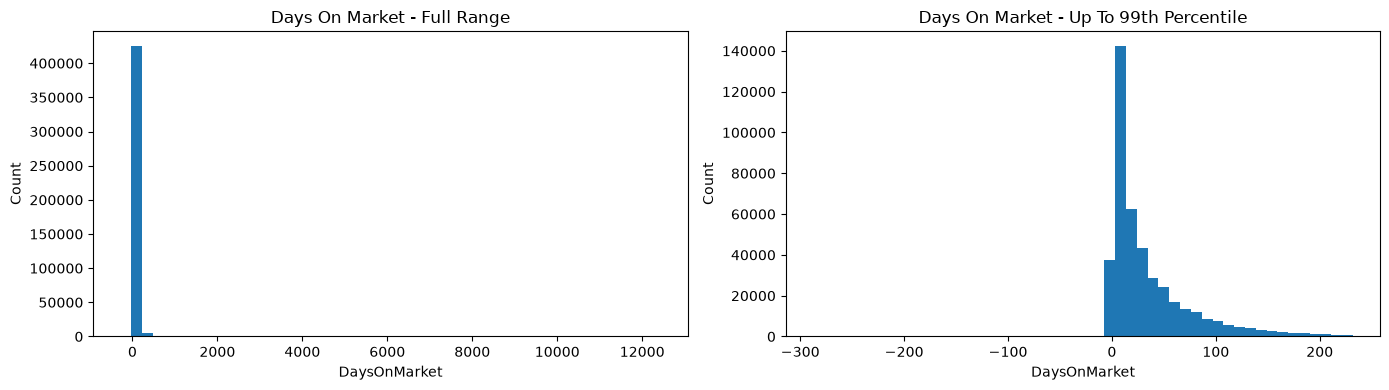

In [13]:
dom_clean = days_on_market.dropna()
dom_p99 = dom_clean.quantile(0.99)
dom_zoomed = dom_clean[dom_clean <= dom_p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dom_clean, bins=50)
axes[0].set_title("Days On Market - Full Range")
axes[0].set_xlabel("DaysOnMarket")
axes[0].set_ylabel("Count")

axes[1].hist(dom_zoomed, bins=50)
axes[1].set_title("Days On Market - Up To 99th Percentile")
axes[1].set_xlabel("DaysOnMarket")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "days_on_market_distribution.png")
plt.show()

In [14]:
days_on_market = pd.to_numeric(sold_residential["DaysOnMarket"], errors="coerce")

negative_dom = sold_residential[days_on_market < 0].copy()

print(f"Negative DaysOnMarket rows: {len(negative_dom):,}")
print(f"Negative DaysOnMarket percentage: {len(negative_dom) / len(sold_residential) * 100:.4f}%")
print(f"Minimum DaysOnMarket: {days_on_market.min()}")

negative_dom[
    [
        "ListingId",
        "DaysOnMarket",
        "ListingContractDate",
        "PurchaseContractDate",
        "CloseDate",
        "MlsStatus",
        "PropertySubType",
        "City",
        "CountyOrParish",
        "ListPrice",
        "ClosePrice",
    ]
].sort_values("DaysOnMarket").head(20)

Negative DaysOnMarket rows: 50
Negative DaysOnMarket percentage: 0.0116%
Minimum DaysOnMarket: -288


,ListingId,DaysOnMarket,ListingContractDate,PurchaseContractDate,CloseDate,MlsStatus,PropertySubType,City,CountyOrParish,ListPrice,ClosePrice
309880,SW23076377,-288,2023-05-04,2024-04-26,2025-02-18,Closed,ManufacturedOnLand,Hemet,Riverside,83000.0,105000.0
512002,SR24008510,-265,2024-01-12,2025-07-07,2025-11-06,Closed,SingleFamilyResidence,Ontario,San Bernardino,600000.0,615000.0
131611,SW24060287,-84,2024-03-26,2024-06-03,2024-06-18,Closed,SingleFamilyResidence,San Jacinto,Riverside,899000.0,877000.0
511987,SB24042834,-65,2024-02-08,2025-07-08,2025-11-06,Closed,SingleFamilyResidence,Los Angeles,Los Angeles,675000.0,560000.0
422427,CV25037065,-63,2025-02-12,2025-07-15,2025-07-24,Closed,SingleFamilyResidence,California City,Kern,150000.0,130000.0
38179,C1-10508,-58,2024-01-11,2024-01-22,2024-03-19,Closed,SingleFamilyResidence,Fort Bragg,Mendocino,899000.0,810000.0
57748,219102945DA,-57,2023-11-15,2024-03-21,2024-03-22,Closed,SingleFamilyResidence,Indian Wells,Riverside,1250000.0,1120000.0
208632,PW23052001,-56,2023-03-29,2024-06-11,2024-09-03,Closed,SingleFamilyResidence,Santa Ana,Orange,720000.0,745000.0
38153,V1-22556,-48,2024-01-30,2024-02-02,2024-03-21,Closed,SingleFamilyResidence,Ojai,Ventura,799000.0,799000.0
109473,TR24008085,-43,2024-01-19,2024-04-12,2024-05-21,Closed,SingleFamilyResidence,Rowland Heights,Los Angeles,839000.0,840000.0


## 6. What Percentage Of Homes Sold Above Vs. Below List Price?

In [15]:
list_price = pd.to_numeric(sold_residential["ListPrice"], errors="coerce")
valid_price_pairs = pd.DataFrame({
    "ClosePrice": close_price,
    "ListPrice": list_price,
}).dropna()

above_count = int((valid_price_pairs["ClosePrice"] > valid_price_pairs["ListPrice"]).sum())
below_count = int((valid_price_pairs["ClosePrice"] < valid_price_pairs["ListPrice"]).sum())
at_count = int((valid_price_pairs["ClosePrice"] == valid_price_pairs["ListPrice"]).sum())
total_pairs = len(valid_price_pairs)

sale_to_list_summary = pd.DataFrame([
    {"category": "sold_above_list_price", "row_count": above_count, "share_pct": above_count / total_pairs * 100},
    {"category": "sold_below_list_price", "row_count": below_count, "share_pct": below_count / total_pairs * 100},
    {"category": "sold_at_list_price", "row_count": at_count, "share_pct": at_count / total_pairs * 100},
])

sale_to_list_summary["share_pct"] = sale_to_list_summary["share_pct"].round(2)
sale_to_list_summary

,category,row_count,share_pct
0,sold_above_list_price,172619,40.10
1,sold_below_list_price,183098,42.54
2,sold_at_list_price,74735,17.36


In [16]:
# Check if the sold above list is because of missing values or 0 values.

close_price = pd.to_numeric(sold_residential["ClosePrice"], errors="coerce")
list_price = pd.to_numeric(sold_residential["ListPrice"], errors="coerce")

price_quality_check = pd.DataFrame([
    {
        "total_rows": len(sold_residential),
        "missing_close_price": close_price.isna().sum(),
        "missing_list_price": list_price.isna().sum(),
        "missing_either_price": (close_price.isna() | list_price.isna()).sum(),
        "zero_close_price": (close_price == 0).sum(),
        "zero_list_price": (list_price == 0).sum(),
        "negative_close_price": (close_price < 0).sum(),
        "negative_list_price": (list_price < 0).sum(),
        "valid_positive_price_pairs": (
            close_price.notna()
            & list_price.notna()
            & (close_price > 0)
            & (list_price > 0)
        ).sum(),
    }
])

price_quality_check

,total_rows,missing_close_price,missing_list_price,missing_either_price,zero_close_price,zero_list_price,negative_close_price,negative_list_price,valid_positive_price_pairs
0,430454,2,0,2,1,0,0,0,430451


In [17]:
valid_price_pairs = pd.DataFrame({
    "ClosePrice": close_price,
    "ListPrice": list_price,
}).dropna()

valid_price_pairs = valid_price_pairs[
    (valid_price_pairs["ClosePrice"] > 0)
    & (valid_price_pairs["ListPrice"] > 0)
]

above_count = (valid_price_pairs["ClosePrice"] > valid_price_pairs["ListPrice"]).sum()
below_count = (valid_price_pairs["ClosePrice"] < valid_price_pairs["ListPrice"]).sum()
at_count = (valid_price_pairs["ClosePrice"] == valid_price_pairs["ListPrice"]).sum()
total_count = len(valid_price_pairs)

pd.DataFrame([
    {
        "category": "sold_above_list_price",
        "row_count": above_count,
        "share_pct": above_count / total_count * 100,
    },
    {
        "category": "sold_below_list_price",
        "row_count": below_count,
        "share_pct": below_count / total_count * 100,
    },
    {
        "category": "sold_at_list_price",
        "row_count": at_count,
        "share_pct": at_count / total_count * 100,
    },
])

,category,row_count,share_pct
0,sold_above_list_price,172619,40.101893
1,sold_below_list_price,183097,42.536084
2,sold_at_list_price,74735,17.362023


In [22]:
sold_quarter = sold_residential.copy()

sold_quarter["ClosePriceNumeric"] = pd.to_numeric(
    sold_quarter["ClosePrice"], errors="coerce"
)
sold_quarter["ListPriceNumeric"] = pd.to_numeric(
    sold_quarter["ListPrice"], errors="coerce"
)
sold_quarter["CloseDateParsed"] = pd.to_datetime(
    sold_quarter["CloseDate"], errors="coerce"
)

sold_quarter = sold_quarter[
    sold_quarter["ClosePriceNumeric"].notna()
    & sold_quarter["ListPriceNumeric"].notna()
    & (sold_quarter["ClosePriceNumeric"] > 0)
    & (sold_quarter["ListPriceNumeric"] > 0)
    & sold_quarter["CloseDateParsed"].notna()
].copy()

sold_quarter["YearQuarter"] = sold_quarter["CloseDateParsed"].dt.to_period("Q").astype(str)

sold_quarter["SaleVsList"] = "At List"
sold_quarter.loc[
    sold_quarter["ClosePriceNumeric"] > sold_quarter["ListPriceNumeric"],
    "SaleVsList"
] = "Above List"
sold_quarter.loc[
    sold_quarter["ClosePriceNumeric"] < sold_quarter["ListPriceNumeric"],
    "SaleVsList"
] = "Below List"

quarter_summary = (
    sold_quarter
    .groupby(["YearQuarter", "SaleVsList"])
    .size()
    .reset_index(name="row_count")
)

quarter_summary["share_pct"] = (
    quarter_summary["row_count"]
    / quarter_summary.groupby("YearQuarter")["row_count"].transform("sum")
    * 100
).round(2)

In [23]:
quarter_pivot = quarter_summary.pivot(
    index="YearQuarter",
    columns="SaleVsList",
    values="share_pct"
).fillna(0)

quarter_pivot

SaleVsList,Above List,At List,Below List
YearQuarter,,,
2024Q1,43.52,17.40,39.08
2024Q2,51.04,16.20,32.75
2024Q3,44.51,16.84,38.64
2024Q4,39.86,16.68,43.47
2025Q1,38.58,18.30,43.11
2025Q2,39.57,18.14,42.28
2025Q3,33.67,17.30,49.02
2025Q4,32.51,17.50,50.00
2026Q1,34.65,18.21,47.14


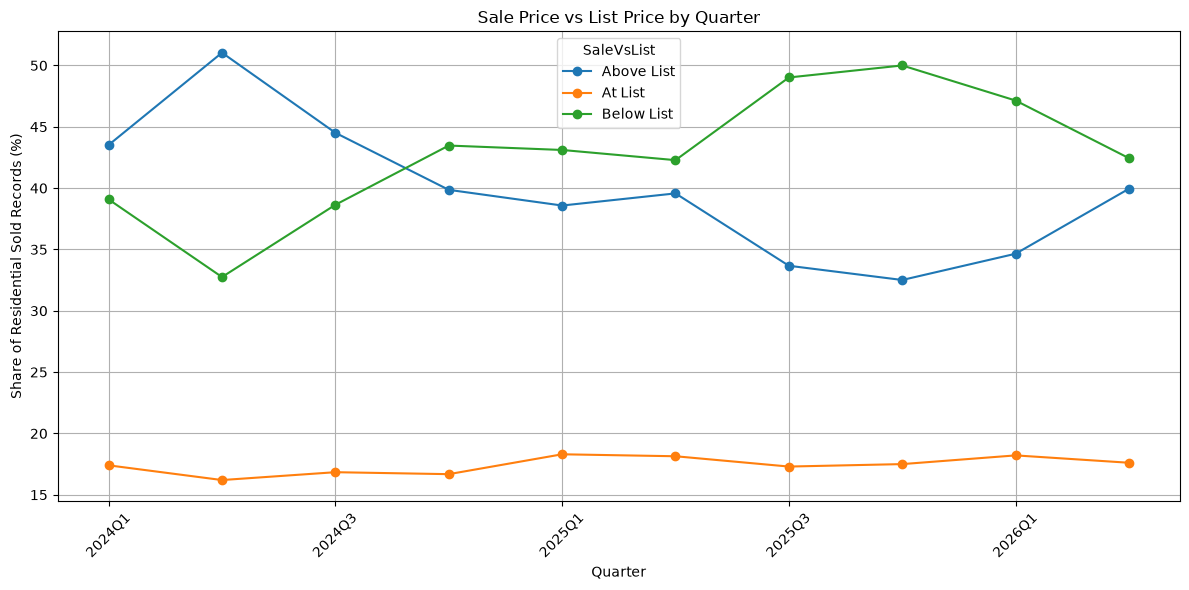

In [24]:
quarter_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Sale Price vs List Price by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Share of Residential Sold Records (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Are There Any Apparent Date Consistency Issues?

In [25]:
close_date = pd.to_datetime(sold_residential["CloseDate"], errors="coerce")
listing_date = pd.to_datetime(sold_residential["ListingContractDate"], errors="coerce")
purchase_date = pd.to_datetime(sold_residential["PurchaseContractDate"], errors="coerce")

date_issue_summary = pd.DataFrame([
    {
        "issue": "CloseDate before ListingContractDate",
        "row_count": int((close_date < listing_date).sum()),
    },
    {
        "issue": "CloseDate before PurchaseContractDate",
        "row_count": int((close_date < purchase_date).sum()),
    },
    {
        "issue": "PurchaseContractDate before ListingContractDate",
        "row_count": int((purchase_date < listing_date).sum()),
    },
    {
        "issue": "Missing CloseDate",
        "row_count": int(close_date.isna().sum()),
    },
    {
        "issue": "Missing ListingContractDate",
        "row_count": int(listing_date.isna().sum()),
    },
    {
        "issue": "Missing PurchaseContractDate",
        "row_count": int(purchase_date.isna().sum()),
    },
])

date_issue_summary

,issue,row_count
0,CloseDate before ListingContractDate,65
1,CloseDate before PurchaseContractDate,240
2,PurchaseContractDate before ListingContractDate,280
3,Missing CloseDate,0
4,Missing ListingContractDate,1
5,Missing PurchaseContractDate,196


## 8. Which Counties Have The Highest Median Prices?

In [26]:
county_median_prices = (
    sold_residential.assign(ClosePriceNumeric=close_price)
    .dropna(subset=["CountyOrParish", "ClosePriceNumeric"])
    .groupby("CountyOrParish")
    .agg(
        sold_count=("ClosePriceNumeric", "size"),
        median_close_price=("ClosePriceNumeric", "median"),
        average_close_price=("ClosePriceNumeric", "mean"),
    )
    .reset_index()
    .sort_values("median_close_price", ascending=False)
)

county_median_prices.head(10)

,CountyOrParish,sold_count,median_close_price,average_close_price
8,Del Norte,1,2485000.0,2.485000e+06
45,San Mateo,7529,1700000.0,2.196160e+06
47,Santa Clara,19045,1600000.0,1.924528e+06
42,San Francisco,990,1199950.0,1.328168e+06
48,Santa Cruz,3106,1199444.0,1.349262e+06
31,Orange,48404,1180000.0,1.538160e+06
22,Marin,150,1172500.0,1.355479e+06
0,Alameda,20343,1140000.0,1.312265e+06
33,Other County,5,1100000.0,7.625800e+07
1,Alpine,1,1100000.0,1.100000e+06


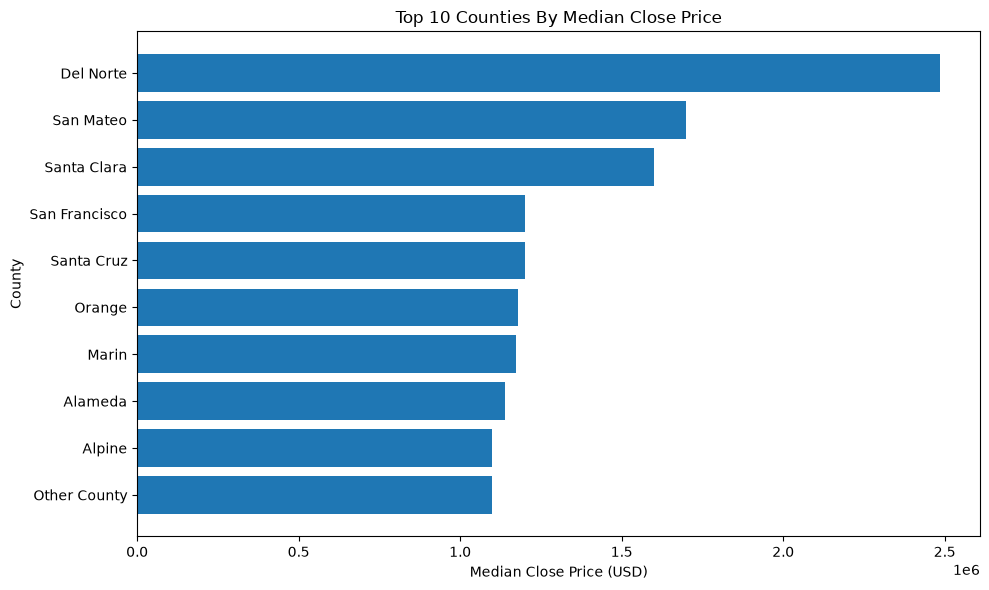

In [27]:
top_counties = county_median_prices.head(10).sort_values("median_close_price")

plt.figure(figsize=(10, 6))
plt.barh(top_counties["CountyOrParish"], top_counties["median_close_price"])
plt.title("Top 10 Counties By Median Close Price")
plt.xlabel("Median Close Price (USD)")
plt.ylabel("County")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_counties_median_close_price.png")
plt.show()

## 9. Save Question Outputs

In [28]:
property_type_summary.to_csv(REPORT_DIR / "property_type_share.csv", index=False)
close_price_summary.to_csv(REPORT_DIR / "close_price_summary.csv", index=False)
dom_summary.to_frame(name="DaysOnMarket").to_csv(REPORT_DIR / "days_on_market_summary.csv")
sale_to_list_summary.to_csv(REPORT_DIR / "sale_to_list_summary.csv", index=False)
date_issue_summary.to_csv(REPORT_DIR / "date_issue_summary.csv", index=False)
county_median_prices.to_csv(REPORT_DIR / "county_median_close_prices.csv", index=False)

print("Saved reports to:", REPORT_DIR)
print("Saved figures to:", FIGURE_DIR)

Saved reports to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/week2_3_sold_questions
Saved figures to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/week2_3_sold_questions/figures
